<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Practico de Laboratorio

Autor: *Olea Gasalla Ignacio Ezequiel y Mariano Lapilli*

*Fecha de entrega: viernes 21 de agosto de 2026*

#### **Consigna** 
[👉  Utilizando el método de Storch ( pag. 403 del Schaumann ) obtener la $T(s)$ Bessel de orden **N = 2, 3 y 4**. ](#mds) 

[👉  Elegir la T(s) con el **mínimo orden** que cumple con $\alpha_{máx}=1dB$.](#ort) 

[👉  Evaluar el Retardo de Grupo $D(2.5)$. Expresar en forma porcentual (%) el error o desviamiento respecto a $D(0)$.](#erg) 

[👉  Sintetizar el circuito normalizado con estructuras Sallen-Key con K=1 ( realimentación negativa unitaria ).](#osk) 

##### **Bonus**:
[💎 Simulación numérica en python utilizando la función pretty_print_lti( num, den ) para el 1).](#mds) 

[💎 Desnormalizar los componentes para obtener un $D(0)=200\mu s$.](#osk) 
 
[💎 Simulación Circuital con los valores desnormalizados. Medir el  $D(\omega)$ resultante (*) indicar con un marker el en banda de paso.](#src) 


##### **Anexo**:
📎 En caso de no poder acceder al documento, presione aquí: [Mostrar PDF](./tc2_ts3.pdf)

📎 Recordar ejecutar el cuadro siguiente de librerias:

In [1]:
# Importo las librerias
import math
import sympy as sp
import numpy as np
import scipy.signal as sig
from sympy import Eq
from IPython.display import display, IFrame, Math
from matplotlib import pyplot as plt
from scipy.signal import TransferFunction

from pytc2.sistemas_lineales import pretty_print_lti, pzmap, GroupDelay, bodePlot, pretty_print_SOS, tf2sos_analog, pretty_print_bicuad_omegayq,tf2zpk, parametrize_sos, analyze_sys
from pytc2.general import s, w, print_latex, a_equal_b_latex_s, print_subtitle, Chebyshev_polynomials

# Función para mostrar en formato de ingenieria las unidades
def eng_format(value, unit=""):
    import numpy as np
    if value == 0:
        return f"0 {unit}"
    exp = int(np.floor(np.log10(abs(value)) / 3) * 3)
    scaled = value / (10**exp)
    prefixes = {-12: "p",-9: "n",-6: "u",-3: "m",0: "",3: "k",6: "M",9: "G"}
    prefix = prefixes.get(exp, f"e{exp}")
    return f"{scaled:.1f} {prefix}{unit}"

#--------------------------------------------------------------------------

<a id="pre"></a>
## **Pre-Lab**

<a id="ort"></a>
#### **Función transferencia**
En el siguiente bloque de código se encuentra el valor de la transferencia con los componentes con valores generales y con los valores usados, además de un gráfico de como se desarrolla la transferencia con los valores utilizados:


Función transferencia con componentes simbólicos:


Eq(T(s), (C**3*R**3*R0*s**3 + C**3*R**3*R1*s**3 + C**2*R**2*R0*s**2 + C**2*R**2*R1*s**2 + C*R*R0*s + C*R*R1*s + R0 + R1)/(C**3*R**3*R0*s**3 + C**3*R**3*R1*s**3 + C**2*R**2*R0*s**2 + 5*C**2*R**2*R1*s**2 + C*R*R0*s + 5*C*R*R1*s + R0 + R1))


Función transferencia y componentes utilizados:


Eq(T(s), (1.0*s**2 + 9.87e+4)/(1.0*s**2 + 10.0*s + 9.87e+4))

   C  = 47.0 nF 
   R  = 67.7 kΩ 
   R0 = 124.7 kΩ 
   R1 = 1.0 kΩ 

Función transferencia usada para el gráfico:


<IPython.core.display.Math object>

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia [Hz]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia [Hz]', ylabel='Retardo de grupo [seg]'>]]

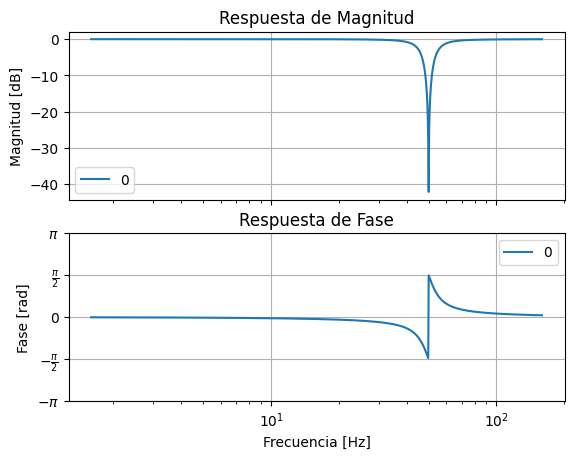

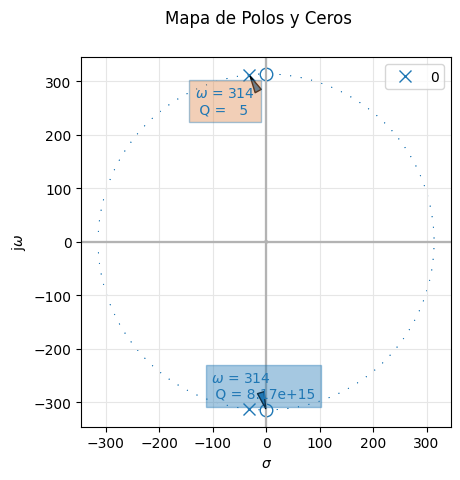

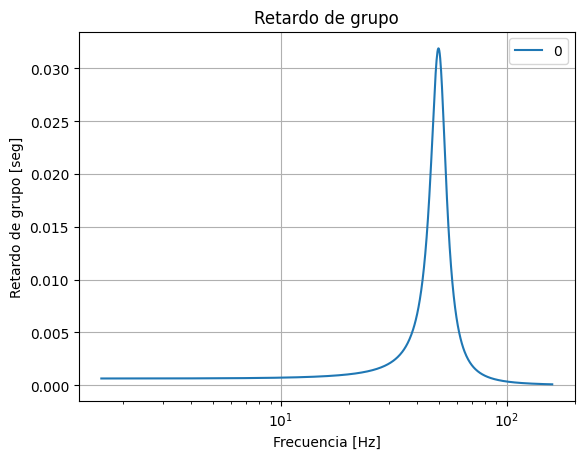

In [2]:
# Se declaran variable simbolicas:
s = sp.symbols('s')
C1, C2, C3, R0, R1, R2, R3, R4 = sp.symbols('C1 C2 C3 R0 R1 R2 R3 R4', positive=True, real=True)
Vi, Vo, V1, V2, Vx = sp.symbols('Vi Vo V1 V2 Vx')

G0 = 1/R0
G1 = 1/R1
G2 = 1/R2
G3 = 1/R3
G4 = 1/R4

# Se expresa las ecuaciones de nodos:
#eq1 = (Vx - Vi)*G0 + (Vx - V2)*G2 + (Vx - V1)*s*C1 
eq1 = (Vi - Vx)*G0 + (Vi - Vo)*G1  # E
eq2 = (V1 - Vx)*s*C1 + (V1 - Vo)*s*C2 + V1*G4 
eq3 = (V2 - Vx)*G2 + (V2 - Vo)*G3 + V2*s*C3 
eq4 = (Vo - V2)*G3 + (Vo - V1)*s*C2 

sol = sp.solve([eq1, eq2, eq3, eq4], (V1 , V2 , Vx, Vo))
# -------------------------------------------------------------------------------------------------------------------------------

# Se arma la transferencia: 
H = sp.simplify(sol[Vo] / Vi) 

C, R = sp.symbols('C R', positive=True, real=True)

C1_ = C
C2_ = C
C3_ = 2*C
R2_ = R
R3_ = R
R4_ = R/2

# Se reemplazan los componentes simbolicos:
H = sp.simplify(H).subs({ R2:(R2_) , R3:(R3_) , R4:(R4_) , C1:(C1_) , C2:(C2_) , C3:(C3_) })

# Se imprime la transferencia:
print('\n'rf"Función transferencia con componentes simbólicos:")
display(Eq(sp.Function('T')(s), H))


# Valores usados:
f0 = 50 # 50 Hz
B  = 10 # 10 Hz

C_  = 47e-9
R1_ = 1e3
R_  = 1 / (2*np.pi*f0 * C_)
R0_ = (4* (2*np.pi*f0 / B) -1) * R1_ 

# Se reemplazan los componentes con los valores necesarios:
H = sp.simplify(H).subs({ R:(R_) , R0:(R0_) , R1:(R1_) , C:(C_) }).evalf(4)

# Se imprime de forma mónica la trasferencia:
num, den = H.as_numer_denom()
coef = sp.Poly(den, s).all_coeffs()[0]
H = sp.simplify((num/coef) / (den/coef))
print('\n'rf"Función transferencia y componentes utilizados:")
display(Eq(sp.Function('T')(s), H))

print(rf"   C  = {eng_format(C_ , 'F')} ")
print(rf"   R  = {eng_format(R_ , 'Ω')} ")
print(rf"   R0 = {eng_format(R0_, 'Ω')} ")
print(rf"   R1 = {eng_format(R1_, 'Ω')} ")

# Se ingresa la transferencia para el gráfico:
num_ = [ 1 , 0 , 9.87e4 ]
den_ = [ 1 , 62.83 , 9.87e4 ]

# Se grafica la transferencia obtenida:
mi_tf = sig.TransferFunction(num_,den_)
this_sos = tf2sos_analog(num_, den_)
print('\n'rf"Función transferencia usada para el gráfico:")
pretty_print_SOS(this_sos, mode='omegayq')
analyze_sys( mi_tf , xaxis='freq' )

In [41]:
IFrame("./tc2_ts3.pdf", width=1000, height=1000)

<a id="mds"></a>
#### **Método de Storch**
 El método de Storch permite obtener filtros Bessel-Tomson con poco trabajo: una vez decidido el orden del filtro, se obtiene la representación en serie de Fourier de la cotangente, esta da como resultado una división de polinomios que Storch los suma para formar "el polinomio de Storch" que tiene la caracteristica de que es identico al denominador de la transferencia de un Bessel-Tomson del mismo orden, asi mismo si se lo evalua en $s=0$ se obtendrá un valor que representa el numerador del Bessel. Permite ahorrar pasos matematicos y es útil para la construcción de estos filtros. 

In [79]:
# Transferencia de orden 2:
num_2 = [3]
den_2 = [1 , 3 , 3]
print(rf"T(s) con n=2:")
pretty_print_lti( num_2 , den_2 )

# Transferencia de orden 3:
num_3 = [15]
den_3 = [1 , 6 , 15 , 15]
print('\n'rf"T(s) con n=3:")
pretty_print_lti( num_3 , den_3 )

# Transferencia de orden 4:
num_4 = [105]
den_4 = [1 , 10 , 45 , 105 , 105]
print('\n'rf"T(s) con n=4:")
pretty_print_lti( num_4 , den_4 )

T(s) con n=2:


<IPython.core.display.Math object>


T(s) con n=3:


<IPython.core.display.Math object>


T(s) con n=4:


<IPython.core.display.Math object>

<a id="ort"></a>
#### **Orden Mínimo de T(s)**
Luego de los calculos hechos en el documento superior, se encontró que el mínimo orden necesario para cumplir $\alpha_{máx}=1dB$ es:
\begin{equation}
\begin{cases} 
    \xi^2 = 0.2589
        \\\\
    n = 2
\end{cases}
\end{equation}

<a id="erg"></a>
#### **Evalución del Retardo de Grupo**
Al igual que el orden mínimo a cumplir, luego de los calculos hechos en el documento superior utilizando la formula de retardo de grupo con la ubicación de los polos y ceros (nuestra función transferencia tiene Ceros en el infinito por lo que no entrará en juego el segundo termino de la ecuación):
\begin{equation}
    D(w) = \sum_{j} \left( \frac{\sigma_j}{\sigma_j^2 + (\omega - \omega_j)^2} \right) - \sum_{i} \left( \frac{\sigma_i}{\sigma_i^2 + (\omega - \omega_i)^2} \right)
\end{equation}

De esta forma, resultó como:
\begin{equation}
\begin{cases} 
    D(0) = 1
        \\\\
    D(2.5) = 0.415
        \\\\
    \Delta D\% = (D(0)-D(2.5)).100\% = 58.4\%
\end{cases}
\end{equation}

<a id="osk"></a>
#### **Obtención del Circuito Sallen-Key**


Función transferencia con componentes simbólicos:


Eq(T(s), (C1*C2*C3*R1*R2*R3*R4*s**3 + C1*C2*C3*R1*R2*R3*R5*s**3 + C1*C2*R1*R3*R4*s**2 + C1*C2*R1*R3*R5*s**2 + C1*C2*R2*R3*R4*s**2 + C1*C2*R2*R3*R5*s**2 + C1*R3*R4*s + C1*R3*R5*s + C2*R3*R4*s + C2*R3*R5*s + R4 + R5)/(C1*C2*C3*R1*R2*R3*R4*s**3 + C1*C2*C3*R1*R2*R3*R5*s**3 + C1*C2*R1*R3*R4*s**2 + C1*C2*R1*R3*R5*s**2 + C1*C2*R2*R3*R4*s**2 + C1*C2*R2*R3*R5*s**2 + C1*C3*R1*R3*R4*s**2 + C1*R3*R4*s + C1*R3*R5*s + C2*C3*R1*R2*R4*s**2 + C2*C3*R1*R3*R4*s**2 + C2*R1*R4*s + C2*R2*R4*s + C2*R3*R4*s + C2*R3*R5*s + C3*R1*R4*s + R4 + R5))

   C1 = 10.0 nF 
   C2 = 10.0 nF 
   C3 = 20.0 nF 
   R1 = 318.3 kΩ 
   R2 = 318.3 kΩ 
   R3 = 159.2 kΩ 
   R4 = 75.0 kΩ 
   R5 = 25.0 kΩ 

Función transferencia:


Eq(T(s), (1.0*s**3 + 314.2*s**2 + 9.87e+4*s + 3.1e+7)/(1.0*s**3 + 1257.0*s**2 + 3.947e+5*s + 3.1e+7))

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia [Hz]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia [Hz]', ylabel='Retardo de grupo [seg]'>]]

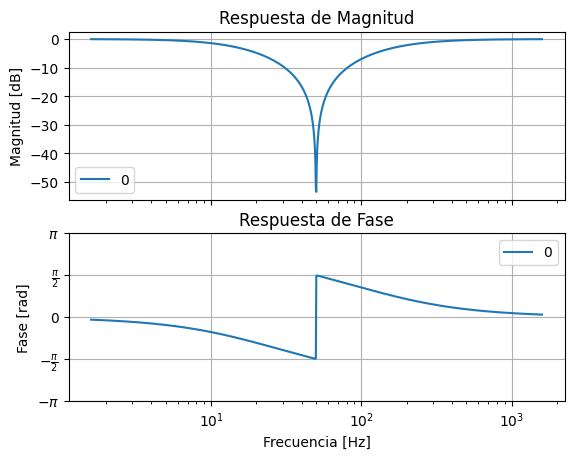

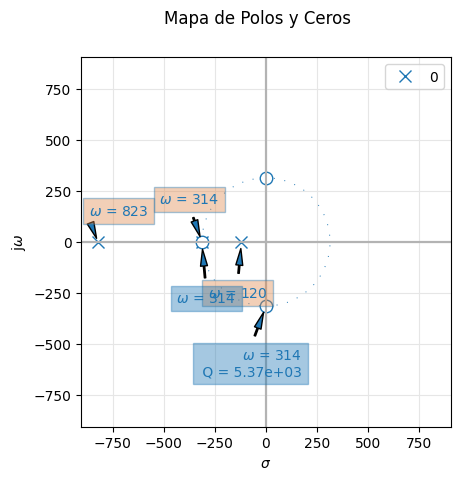

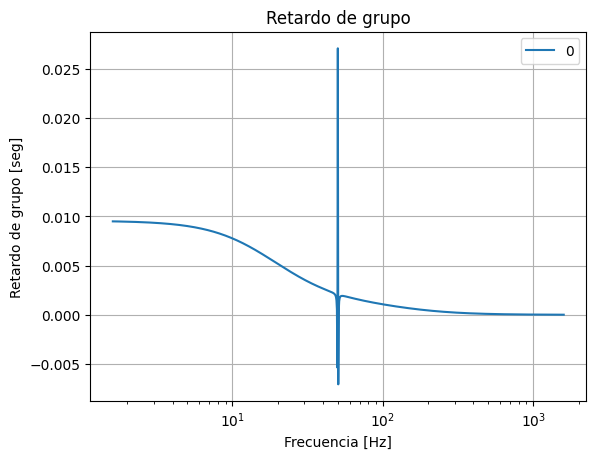

In [26]:
# Se elije el nivel de impedancia, el retardo en s=0 y se debe escribir el num y den de la transferencia si se la quiere graficada:
Z = 1

# Se declaran variable simbolicas:
s = sp.symbols('s')
C1, C2, C3, R1, R2, R3, R4, R5 = sp.symbols('C1 C2 C3 R1 R2 R3 R4 R5', positive=True, real=True)
Vi, Vo, V1, V2 = sp.symbols('Vi Vo V1 V2')
G1 = 1/R1
G2 = 1/R2
G3 = 1/R3

# Se expresa las ecuaciones de nodos:
eq1 = (V1 - Vi)*s*C1 + (V1 - Vo)*s*C2 + (V1 - Vo*(R5 / (R4+R5)) )*G3
eq2 = (V2 - Vi)*G1 + (V2 - Vo)*G2 + (V2 - Vo*(R5 / (R4+R5)) )*s*C3
eq3 = (Vo - V1)*s*C2 + (Vo - V2)*G2
# Vx = Vo*(R5 / (R4+R5))

sol = sp.solve([eq1, eq2, eq3], (V1,V2, Vo))

# Se arma y presenta la transferencia: 
H = sp.simplify(sol[Vo] / Vi) 
print('\n'rf"Función transferencia con componentes simbólicos:")
display(Eq(sp.Function('T')(s), H))

# Se elijen valores de componentes correspondientes para crear un Filtro Bessel (demostrado en el documento superior):

C1_ = 10e-9 * Z
C2_ = 10e-9 * Z
C3_ = 20e-9 * Z
R1_ = 318.3e3 / Z
R2_ = 318.3e3 / Z
R3_ = 159.2e3 / Z
R4_ = 75e3 / Z
R5_ = 25e3 / Z

'''
C1_ = 10   *sp.Pow(10,-9) 
C2_ = 10   *sp.Pow(10,-9) 
C3_ = 20   *sp.Pow(10,-9)  
R1_ = 318.3*sp.Pow(10,3) 
R2_ = 318.3*sp.Pow(10,3) 
R3_ = 159.2*sp.Pow(10,3) 
R4_ = 75   *sp.Pow(10,3) 
R5_ = 25   *sp.Pow(10,3)  
'''
# Se reemplaza por la transferencia elegida:
H = sp.expand(H).subs({ R1:(R1_) , R2:(R2_) , R3:(R3_) , R4:(R4_) , R5:(R5_) , C1:(C1_) , C2:(C2_) , C3:(C3_) }).evalf(4)
num, den = H.as_numer_denom()
coef = den.coeff(s, 3)
H = sp.together((num/coef) / (den/coef))

# Se imprime los valores de los compontes con su respectiva norma de impedancia y la transferencia resultante:

#print('\n'rf"Los valores a usar para un nivel de impedancia Z = {eng_format(Z, "")} y un D(0) = {eng_format(w, "s")} son:")
print(rf"   C1 = {eng_format(C1_, 'F')} ")
print(rf"   C2 = {eng_format(C2_, 'F')} ")
print(rf"   C3 = {eng_format(C3_, 'F')} ")
print(rf"   R1 = {eng_format(R1_, 'Ω')} ")
print(rf"   R2 = {eng_format(R2_, 'Ω')} ")
print(rf"   R3 = {eng_format(R3_, 'Ω')} ")
print(rf"   R4 = {eng_format(R4_, 'Ω')} ")
print(rf"   R5 = {eng_format(R5_, 'Ω')} ")

print('\n'rf"Función transferencia:")
display(Eq(sp.Function('T')(s), H))

# Ingresar transferencia
num_ = [ 1 , 314.2 , 9.87e4 , 3.1e7 ]
den_ = [ 1 , 1257 , 3.947e5 , 3.1e7 ]

# Se grafica la transferencia obtenida:
mi_tf = sig.TransferFunction(num_,den_)
analyze_sys( mi_tf , xaxis='freq' )

#this_sos = tf2sos_analog(num_, den_)
#print('\n'rf"Función transferencia usada para el gráfico:")
#pretty_print_SOS(this_sos, mode='omegayq')
